In [1]:
#MakeMore Part2

In [2]:
#上一节我们用两种方式实现了bigram
#效果不错，但是bigram有个明显的缺陷就是精确度不够
#因为我们的参照太少了，只根据上一个字母来推测下一个字母
#于是乎我们可以考虑添加些上下文？

In [3]:
#但是这又有个很明显的问题
#如果我们用bigram的思路，直接查表
#那么这个表格随着上下文的增长会出现指数级的增长
#比如如果我们用两个字符来决定下一个字母，那么就会出现27*27=729行
#如果用3个会直接变成27*27*27=19683行
#这显然不可接受

In [4]:
#于是本篇我们将学习使用MLP，也就是在micrograd里实现的方法来完成这个模型
#论文已经添加到文件夹下

In [5]:
# andrej这里带我们简单读了下论文
# MLP的本质就是希望模型能够“解释”单词（或者任何语言的单位，在makemore里我们的单位是字符，论文里是单词）
# 我们正常是怎么解释单词的呢？比如说：
# 如果你要给一个人解释“狗dog”这个词
# 我们会说“这和猫一样都是宠物”
# 所以其实我们会发现，语言的“解释”在很大程度上其实是“近义词”的意思
# 就是说我们并不会创造一个新的东西来解释语言
# 而是用语言本身来解释语言
# 所以说MLP的哲学就在于：既然语言本身就能解释语言，那我就去寻找这些语言间的关系
# 所以MLP给每个单词都添加了一个30维的向量，并来微调他们
# 于是乎每一个单词便有了自己在这个30维向量里的位置
# 而我们调整它们之间的位置关系，就可以用距离远近来表示它们之间的关系
# 这就是MLP的基本哲学
# 接下来我们用代码实现这个MLP

In [6]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline
#环境导入，和之前的环境是一样的，前两行是torch，后两行是画图工具

In [7]:
words=open("names.txt","r").read().splitlines()
words[:3]
#还是一样导入words

['emma', 'olivia', 'ava']

In [8]:
len(words)

32033

In [9]:
chars=sorted(list(set(''.join(words))))
stoi={s:i+1 for i,s in enumerate(chars)}
stoi['.']=0
itos={i:s for s,i in stoi.items()}
print(itos)
#还是一样建立字符数字表

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [10]:
#接下来我们要像之前一样去建造训练集
#还是一样的：一个xs一个ys一一对应
#但是这次我们要不一样一点：
#我们这次不再是单字节模式了
#也就是说我们推测下一个字符不再只看上一个字符，而是要看更多的东西

block_size=3

X,Y=[],[]

for w in words[:5]:
    
    print(w)
    context=[0]*block_size
    for ch in w+'.':
        ix=stoi[ch]
        X.append(context)
        Y.append(ix)
        print(''.join(itos[i] for i in context),"---->",itos[ix])
        context=context[1:]+[ix]
    print("========")

X=torch.tensor(X)
Y=torch.tensor(Y)

emma
... ----> e
..e ----> m
.em ----> m
emm ----> a
mma ----> .
olivia
... ----> o
..o ----> l
.ol ----> i
oli ----> v
liv ----> i
ivi ----> a
via ----> .
ava
... ----> a
..a ----> v
.av ----> a
ava ----> .
isabella
... ----> i
..i ----> s
.is ----> a
isa ----> b
sab ----> e
abe ----> l
bel ----> l
ell ----> a
lla ----> .
sophia
... ----> s
..s ----> o
.so ----> p
sop ----> h
oph ----> i
phi ----> a
hia ----> .


In [11]:
#我们可以看到，Part1是字符->字符
#现在是”字符块“->字符，逻辑类似于滚动窗口
#对于前几个字符块左边空的部分用...填充

In [12]:
#并且显然我们是可以自由调整这个字符块的大小的
block_size=10

X,Y=[],[]

for w in words[:5]:
    
    print(w)
    context=[0]*block_size
    for ch in w+'.':
        ix=stoi[ch]
        X.append(context)
        Y.append(ix)
        print(''.join(itos[i] for i in context),"---->",itos[ix])
        context=context[1:]+[ix]
    print("========")

X=torch.tensor(X)
Y=torch.tensor(Y)

emma
.......... ----> e
.........e ----> m
........em ----> m
.......emm ----> a
......emma ----> .
olivia
.......... ----> o
.........o ----> l
........ol ----> i
.......oli ----> v
......oliv ----> i
.....olivi ----> a
....olivia ----> .
ava
.......... ----> a
.........a ----> v
........av ----> a
.......ava ----> .
isabella
.......... ----> i
.........i ----> s
........is ----> a
.......isa ----> b
......isab ----> e
.....isabe ----> l
....isabel ----> l
...isabell ----> a
..isabella ----> .
sophia
.......... ----> s
.........s ----> o
........so ----> p
.......sop ----> h
......soph ----> i
.....sophi ----> a
....sophia ----> .


In [13]:
#现在的字符块就是10，可以看到...变得越来越多
#我们还是采用3作为字符块大小，这样符合论文里图示的内容

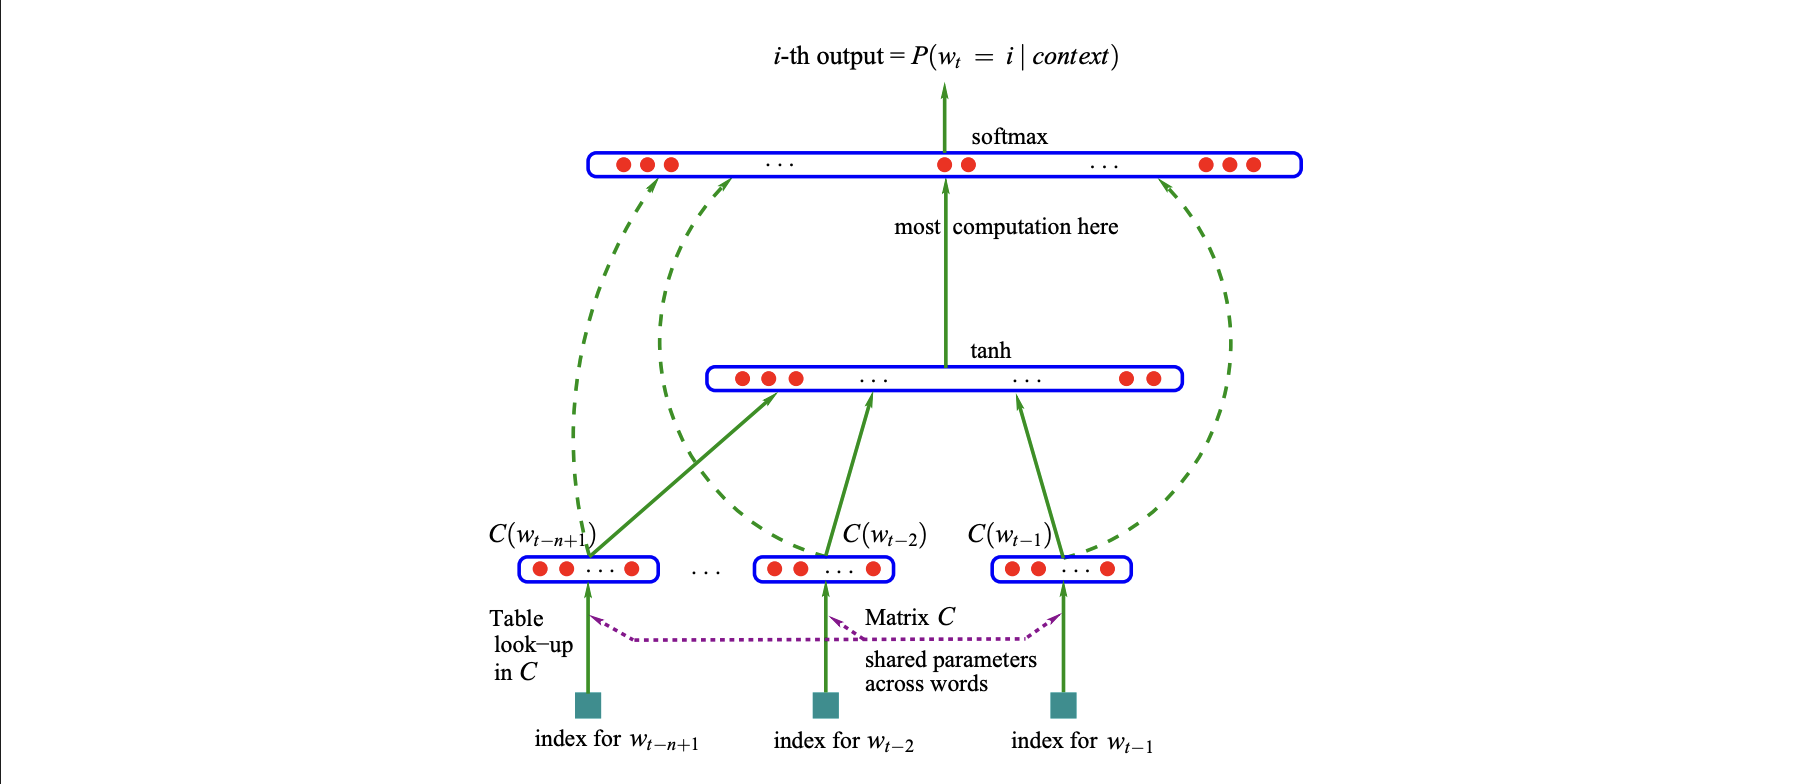

In [14]:


block_size=3

X,Y=[],[]

for w in words:
    context=[0]*block_size
    for ch in w+'.':
        ix=stoi[ch]
        X.append(context)
        Y.append(ix)
        context=context[1:]+[ix]

X=torch.tensor(X)
Y=torch.tensor(Y)

In [15]:
X.shape,X.dtype,Y.shape,Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [16]:
#可以看到总共有228146个字符块和字符的一一对应

In [17]:
#接下来我们要创建论文中的”嵌入矩阵“
#具体来说就是每一个字符不在只代表一个值
#而是一个多维向量
#这里我们简单采用二维向量
C=torch.randn((27,2))
C

tensor([[-1.5680,  0.2373],
        [-0.8498,  0.4974],
        [ 1.2925,  1.9518],
        [ 0.0249,  1.1792],
        [ 1.0301,  0.2110],
        [ 0.8372, -0.5080],
        [ 0.1320,  0.0983],
        [ 0.9911, -0.3050],
        [ 0.8958,  0.3412],
        [ 0.5148, -0.6347],
        [ 0.9819, -0.2032],
        [-0.3101, -0.0187],
        [-0.0146,  0.5417],
        [-1.6534,  1.0752],
        [-0.7528,  0.3974],
        [ 0.4433, -1.2883],
        [-0.8657, -1.0504],
        [ 0.2718,  0.4276],
        [-0.8740,  1.0952],
        [ 0.2050, -0.0714],
        [-0.2073,  0.1751],
        [ 0.5067, -0.1814],
        [ 1.1300,  0.2302],
        [ 0.4593, -1.6882],
        [ 0.6293,  0.8207],
        [-0.1047, -1.7308],
        [ 0.2677, -0.7523]])

In [18]:
#接下来展示操作方法。比如说对于字符c，我可以去提取第三行
C[3]

tensor([0.0249, 1.1792])

In [19]:
#这就是c所对应的嵌入向量
#其实Part1我们就已经使用过这种方式了
#还记得独热向量吗，其实那一步的数学本质就是在取出一行向量
a=F.one_hot(torch.tensor(5),27).float()
a@C

tensor([ 0.8372, -0.5080])

In [20]:
#结果是一样的

In [21]:
#但是我们刚刚只取了一行，对于X来说一次要取3行
#pytorch实现了非常强大的功能可以简便的实现这个目标
C[[5,6,7]]

tensor([[ 0.8372, -0.5080],
        [ 0.1320,  0.0983],
        [ 0.9911, -0.3050]])

In [22]:
#这样就一次性取出来三行了
#也可以一次性取出所有的X
emb=C[X]
emb.shape

torch.Size([228146, 3, 2])

In [23]:
#具体原理是：X[,]会取出一个数字
#再用这个数字取出C里的值去组装
X[10,1]

tensor(22)

In [24]:
C[X[10,1]]

tensor([1.1300, 0.2302])

In [25]:
C[22]

tensor([1.1300, 0.2302])

In [26]:
#可以发现C[22]和C[X[10,1]]是一样的

In [27]:
#这样的话嵌入层就完成了
#这里的话我们先只用5个单词的输入作为示例,避免后面打印的时候太长了

block_size=3

X,Y=[],[]

for w in words[:5]:
    context=[0]*block_size
    for ch in w+'.':
        ix=stoi[ch]
        X.append(context)
        Y.append(ix)
        context=context[1:]+[ix]

X=torch.tensor(X)
Y=torch.tensor(Y)
emb=C[X]
#接下来实现隐藏层

In [28]:
#首先看，这个隐藏层接收的输入会是三个输入的嵌入向量，每个嵌入向量有两个量，所以是3*2=6
#我们假设总共有100个神经元，设置W和b
W1=torch.randn((6,100))
b1=torch.rand(100)

In [29]:
#但是现在有一个问题：
emb.shape,W1.shape

(torch.Size([32, 3, 2]), torch.Size([6, 100]))

In [30]:
#emb是228146*3*2的，W1是6*100的，做不了乘法
#emb@W1+b1
#这一行会报错
#好在pytorch是一个功能强大的库
#提供了一个cat函数可以拼接张量
#还有一个unbind函数用于删除一个维度转而用元组表示

In [31]:
torch.cat([emb[:,0,:],emb[:,1,:],emb[:,2,:]],1).shape

torch.Size([32, 6])

In [32]:
torch.cat(torch.unbind(emb,1),1).shape

torch.Size([32, 6])

In [33]:
#其实torch还有一种非常高效的方式
a=torch.arange(24)
a

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23])

In [34]:
a.shape

torch.Size([24])

In [35]:
a.view(2,12)

tensor([[ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11],
        [12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]])

In [36]:
a.view(4,2,3)

tensor([[[ 0,  1,  2],
         [ 3,  4,  5]],

        [[ 6,  7,  8],
         [ 9, 10, 11]],

        [[12, 13, 14],
         [15, 16, 17]],

        [[18, 19, 20],
         [21, 22, 23]]])

In [37]:
#很神奇吧，这是pytorch的view方法
#因为torch内部本身其实是线性排列的
a.storage()

/var/folders/bj/h9w4f26d58vc04wvwhk6kd580000gn/T/ipykernel_94063/3125828718.py:3: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  a.storage()


 0
 1
 2
 3
 4
 5
 6
 7
 8
 9
 10
 11
 12
 13
 14
 15
 16
 17
 18
 19
 20
 21
 22
 23
[torch.storage.TypedStorage(dtype=torch.int64, device=cpu) of size 24]

In [38]:
#所以只要view里的乘积是总数量就可以了
#而且view有个很高效的地方在于：它是在原地进行操作的
#之前的两个操作都会创建新的对象占用内存空间

In [39]:
#所以现在回过头来发现其实一个view()就可以了
emb.shape

torch.Size([32, 3, 2])

In [40]:
emb.view(32,6).shape

torch.Size([32, 6])

In [41]:
#还有更方便的，torch可以自己推理，用-1就是告诉torch这里要填一个符合最终惩罚结果的数字
emb.view(-1,6).shape

torch.Size([32, 6])

In [42]:
#这样就可以用乘法了
h=emb.view(-1,6) @ W1 + b1
#这里也要小心！
#b1的形状是(100)
#所以这里会涉及到广播机制
#32 100
#100
#根据广播机制b1会扩展成32 100
#所以是可行的
h.shape

torch.Size([32, 100])

In [43]:
h

tensor([[ 0.0098,  2.9192,  3.6842,  ..., -2.1659,  3.3309, -0.1799],
        [ 0.6782,  4.3033,  0.3818,  ..., -0.2669,  3.1503, -0.0603],
        [ 1.9645,  2.1154,  1.8001,  ..., -0.5825,  3.1058, -0.3072],
        ...,
        [-0.3894, -2.2469, -1.9143,  ...,  1.7569,  1.3686,  0.8102],
        [ 1.5923,  0.8271,  1.6298,  ...,  0.8047,  1.3529,  2.2913],
        [-0.5170, -1.0301, -0.8824,  ...,  0.3255, -1.4974,  0.5554]])

In [44]:
#神经网络最后一步还需要tanh来平滑化
h=torch.tanh(h)
h

tensor([[ 0.0098,  0.9942,  0.9987,  ..., -0.9741,  0.9974, -0.1780],
        [ 0.5903,  0.9996,  0.3643,  ..., -0.2608,  0.9963, -0.0603],
        [ 0.9614,  0.9713,  0.9468,  ..., -0.5245,  0.9960, -0.2979],
        ...,
        [-0.3708, -0.9779, -0.9574,  ...,  0.9422,  0.8784,  0.6697],
        [ 0.9205,  0.6789,  0.9260,  ...,  0.6667,  0.8747,  0.9797],
        [-0.4754, -0.7739, -0.7076,  ...,  0.3145, -0.9047,  0.5046]])

In [45]:
#于是我们就得到了隐藏层激活值

In [46]:
#好的接下来我们来创建最后一个输出层
#这一层应该接住隐藏层传过来的激活值然后输出logits
W2=torch.randn((100,27))
b2=torch.randn(27)

In [47]:
logits=h@W2+b2

In [48]:
logits.shape

torch.Size([32, 27])

In [49]:
#接下来就是softmax
counts=logits.exp()
probs=counts/counts.sum(1,keepdims=True)
probs.shape

torch.Size([32, 27])

In [50]:
#接下来就是用Y找到那些正确答案的概率
probs[torch.arange(32),Y]

tensor([3.1695e-10, 3.6166e-06, 1.6437e-05, 1.5618e-11, 3.1841e-08, 5.8262e-12,
        7.7490e-04, 3.8352e-03, 7.0921e-09, 2.5485e-06, 5.3364e-06, 4.7712e-02,
        7.5009e-06, 3.1838e-09, 1.1858e-04, 1.8808e-03, 1.9166e-04, 6.8521e-07,
        6.8633e-10, 1.3746e-06, 1.1907e-06, 5.7393e-03, 1.8826e-10, 6.2166e-08,
        1.6004e-02, 2.5855e-02, 1.4519e-09, 2.6194e-12, 3.1958e-09, 3.0092e-12,
        3.5340e-10, 4.0818e-02])

In [51]:
#理想状态下，这些数值应该趋近于1
#所以下一步就是开始训练

In [52]:
#首先计算loss
loss=-probs[torch.arange(32),Y].log().mean()
loss

tensor(14.3959)

In [53]:
#现在前向传播就完成了
#整理下代码

In [54]:
g = torch.Generator().manual_seed(2147483647) #固定随机数
C = torch.randn((27, 2), generator=g)#嵌入层
W1 = torch.randn((6, 100), generator=g)#隐藏层
b1 = torch.randn(100, generator=g)#隐藏层
W2 = torch.randn((100, 27), generator=g)#激活层
b2 = torch.randn(27, generator=g)#激活层
parameters = [C, W1, b1, W2, b2]#所有的总参数，用于后续的梯度清除
for p in parameters:
    p.requires_grad=True

In [55]:
sum(p.nelement() for p in parameters) #总参数量

3481

In [56]:
emb = C[X] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
counts = logits.exp()
prob = counts / counts.sum(1, keepdims=True)
loss = -prob[torch.arange(32), Y].log().mean()
loss

tensor(17.7697, grad_fn=<NegBackward0>)

In [57]:
#同时，pytorch实现了我们最后从logits到loss的那一步
#这一步就是cross_entropy,中文翻译交叉_熵
emb = C[X] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss=F.cross_entropy(logits,Y)
loss

tensor(17.7697, grad_fn=<NllLossBackward0>)

In [58]:
#同时这一步由于是pytorch的内部方法所以pytorch在里面可以高效地简化反向传播
#并且cross_entropy在面对极大数，比如出现e**100的时候按传统写法会出现nan但是cross_entropy可以很好的处理这些极端情况

In [59]:
#现在前向传播完成，接下来就是清空梯度，反向传播

In [60]:
#反向传播
for p in parameters:
    p.grad=None
loss.backward()
for p in parameters:
    p.data+=-0.1*p.grad

In [61]:
#接下来组合一下
for _ in range(10):
    emb = C[X] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss=F.cross_entropy(logits,Y)

    print(loss.item())
    #反向传播
    for p in parameters:
        p.grad=None
    loss.backward()
    for p in parameters:
        p.data+=-0.1*p.grad

13.656402587890625
11.298770904541016
9.4524564743042
7.984263896942139
6.891321659088135
6.1000142097473145
5.452035903930664
4.898152828216553
4.414663791656494
3.985849142074585


In [62]:
#loss下降到了4左右，如果多训练
for _ in range(1000):
    emb = C[X] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss=F.cross_entropy(logits,Y)

    #反向传播
    for p in parameters:
        p.grad=None
    loss.backward()
    for p in parameters:
        p.data+=-0.1*p.grad

print(loss.item())

0.2560918927192688


In [63]:
#可以发现loss非常的低，拟合度很高
#但这个是因为我们现在的数据量太小了
#只拟合32个当然很好了
logits.max(1),Y

(torch.return_types.max(
 values=tensor([13.3518, 17.8061, 20.5914, 20.6164, 16.7517, 13.3518, 15.9871, 14.1991,
         15.9261, 18.4037, 15.9549, 20.9417, 13.3518, 17.1368, 17.1637, 20.0786,
         13.3518, 16.4702, 15.1487, 17.0690, 18.6017, 15.9800, 10.8867, 10.6986,
         15.5148, 13.3518, 16.2503, 16.9685, 12.7510, 16.2235, 19.0987, 16.0391],
        grad_fn=<MaxBackward0>),
 indices=tensor([ 9, 13, 13,  1,  0,  9, 12,  9, 22,  9,  1,  0,  9, 22,  1,  0,  9, 19,
          1,  2,  5, 12, 12,  1,  0,  9, 15, 16,  8,  9,  1,  0])),
 tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
          1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0]))

In [64]:
#这个是logits给出的最大值的预测，可以发现大部分和正确答案Y拟合的很好
#所以下一步我们就是实现全部的训练

In [65]:
block_size=3

X,Y=[],[]

for w in words:
    context=[0]*block_size
    for ch in w+'.':
        ix=stoi[ch]
        X.append(context)
        Y.append(ix)
        context=context[1:]+[ix]

X=torch.tensor(X)
Y=torch.tensor(Y)

for _ in range(10):
    emb = C[X] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss=F.cross_entropy(logits,Y)
    print(loss.item())
    #反向传播
    for p in parameters:
        p.grad=None
    loss.backward()
    for p in parameters:
        p.data+=-0.1*p.grad

13.646496772766113
13.094269752502441
12.58001708984375
12.099854469299316
11.653829574584961
11.243758201599121
10.868657112121582
10.525008201599121
10.21104621887207
9.924516677856445


In [66]:
#可以看到这次训练慢一些而且loss下降比较缓慢了
#我们加长一下训练规模

In [67]:
block_size=3

X,Y=[],[]

for w in words:
    context=[0]*block_size
    for ch in w+'.':
        ix=stoi[ch]
        X.append(context)
        Y.append(ix)
        context=context[1:]+[ix]

X=torch.tensor(X)
Y=torch.tensor(Y)

for i in range(100):
    emb = C[X] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss=F.cross_entropy(logits,Y)
    if i%5==0:
        print(f"训练轮次:{i},loss={loss.item():.4f}")
    #反向传播
    for p in parameters:
        p.grad=None
    loss.backward()
    for p in parameters:
        p.data+=-0.1*p.grad
print(f"最终结果:loss={loss}")

训练轮次:0,loss=9.6609
训练轮次:5,loss=8.5985
训练轮次:10,loss=7.8184
训练轮次:15,loss=7.1950
训练轮次:20,loss=6.6787
训练轮次:25,loss=6.2464
训练轮次:30,loss=5.8847
训练轮次:35,loss=5.5809
训练轮次:40,loss=5.3233
训练轮次:45,loss=5.1020
训练轮次:50,loss=4.9096
训练轮次:55,loss=4.7409
训练轮次:60,loss=4.5922
训练轮次:65,loss=4.4607
训练轮次:70,loss=4.3433
训练轮次:75,loss=4.2375
训练轮次:80,loss=4.1409
训练轮次:85,loss=4.0521
训练轮次:90,loss=3.9700
训练轮次:95,loss=3.8939
最终结果:loss=3.836977243423462


In [68]:
#运行的时候可以发现运算时间相较于之前长了不少
#甚至我的m5芯片的macbookair都有很明显的发烫了（lol）
#但是chatgpt其实用了数以万亿计的互联网文本作为参考，但是我们现在只有几千个参数，几万个训练对象就开始发烫
#所以我们的思路是：不直接训练所有的对象，而是分批次训练这个模型
#实现方法是随机抽取训练集里的一个个小部分去进行训练

In [69]:
#torch实现了随机整数的功能
torch.randint(0,5,(32,))#最后一个数量参数要是元组

tensor([2, 3, 4, 0, 1, 2, 4, 2, 0, 1, 1, 2, 4, 3, 4, 3, 0, 4, 4, 1, 3, 2, 0, 2,
        4, 4, 3, 4, 4, 2, 3, 2])

In [70]:
torch.randint(1,X.shape[0],(32,))

tensor([187680, 181388, 121523, 134029,  74989, 203640,  50213,  70347, 222484,
        117419, 103189, 139668,    971,  53810, 134448, 116110, 174870, 204510,
        121341, 150195, 209658, 103834,  90269, 172912, 172110, 223591, 182896,
         78793,  49263, 220548, 185426,  74805])

In [71]:
#这里就生成了一个大小为32的小批量训练集
#我们可以先用这个来训练

for i in range(100):
    ix=torch.randint(1,X.shape[0],(32,))
    emb = C[X[ix]] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss=F.cross_entropy(logits,Y[ix])
    if i%5==0:
        print(f"训练轮次:{i},loss={loss.item():.4f}")
    #反向传播
    for p in parameters:
        p.grad=None
    loss.backward()
    for p in parameters:
        p.data+=-0.1*p.grad

emb = C[X] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss=F.cross_entropy(logits,Y)       
print(f"最终结果:整体loss={loss}")

训练轮次:0,loss=4.0645
训练轮次:5,loss=3.6995
训练轮次:10,loss=4.1781
训练轮次:15,loss=4.2914
训练轮次:20,loss=2.8195
训练轮次:25,loss=3.0291
训练轮次:30,loss=3.3003
训练轮次:35,loss=3.0058
训练轮次:40,loss=3.4518
训练轮次:45,loss=3.0117
训练轮次:50,loss=3.3957
训练轮次:55,loss=3.0965
训练轮次:60,loss=3.0386
训练轮次:65,loss=3.5762
训练轮次:70,loss=2.7351
训练轮次:75,loss=3.6224
训练轮次:80,loss=3.5766
训练轮次:85,loss=3.1785
训练轮次:90,loss=2.6337
训练轮次:95,loss=3.4442
最终结果:整体loss=3.2538251876831055


In [72]:
#这次就快了很多
#但是会发现我们的loss出现了起伏
#因为这个训练过程不是固定的，会随机取训练对象
#所以要是随机取到了没怎么训练过的内容就会出现loss倒转
#我们最后计算整体的loss就好了

In [73]:
#让我们多算几遍
for i in range(10000):
    ix=torch.randint(1,X.shape[0],(32,))
    emb = C[X[ix]] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss=F.cross_entropy(logits,Y[ix])

    #反向传播
    for p in parameters:
        p.grad=None
    loss.backward()
    for p in parameters:
        p.data+=-0.1*p.grad
    if i%500==0:
        print(f"训练轮次:{i},loss={loss.item():.4f}")
        emb = C[X] # (32, 3, 2)
        h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
        logits = h @ W2 + b2 # (32, 27)
        loss=F.cross_entropy(logits,Y)       
        print(f"整体loss={loss}\n")

emb = C[X] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss=F.cross_entropy(logits,Y)       
print(f"最终结果:整体loss={loss}")

训练轮次:0,loss=2.7849
整体loss=3.3151144981384277

训练轮次:500,loss=2.9101
整体loss=2.727989673614502

训练轮次:1000,loss=2.6631
整体loss=2.617682695388794

训练轮次:1500,loss=2.5952
整体loss=2.6301333904266357

训练轮次:2000,loss=2.7331
整体loss=2.5638744831085205

训练轮次:2500,loss=2.6659
整体loss=2.5604114532470703

训练轮次:3000,loss=2.5487
整体loss=2.52117657661438

训练轮次:3500,loss=2.9465
整体loss=2.5123603343963623

训练轮次:4000,loss=2.2840
整体loss=2.5236268043518066

训练轮次:4500,loss=2.3222
整体loss=2.506211042404175

训练轮次:5000,loss=2.5568
整体loss=2.4824411869049072

训练轮次:5500,loss=2.2430
整体loss=2.5161821842193604

训练轮次:6000,loss=2.3250
整体loss=2.511013984680176

训练轮次:6500,loss=2.8903
整体loss=2.491450309753418

训练轮次:7000,loss=2.5426
整体loss=2.4927971363067627

训练轮次:7500,loss=2.2170
整体loss=2.508263111114502

训练轮次:8000,loss=2.1922
整体loss=2.5231223106384277

训练轮次:8500,loss=2.4453
整体loss=2.4926087856292725

训练轮次:9000,loss=2.4839
整体loss=2.4870429039001465

训练轮次:9500,loss=2.4054
整体loss=2.4608466625213623

最终结果:整体loss=2.4833145141601562


In [74]:
#我们可以发现：整体loss并没有稳步下降，说明我们在步长上的设计是有问题的
#这里选择步长的方法非常简单粗暴：直接试试看不同的取值loss是怎么变的
#重置参数
g = torch.Generator().manual_seed(2147483647) #固定随机数
C = torch.randn((27, 2), generator=g)#嵌入层
W1 = torch.randn((6, 100), generator=g)#隐藏层
b1 = torch.randn(100, generator=g)#隐藏层
W2 = torch.randn((100, 27), generator=g)#激活层
b2 = torch.randn(27, generator=g)#激活层
parameters = [C, W1, b1, W2, b2]#所有的总参数，用于后续的梯度清除
for p in parameters:
    p.requires_grad=True

block_size=3

X,Y=[],[]

for w in words:
    context=[0]*block_size
    for ch in w+'.':
        ix=stoi[ch]
        X.append(context)
        Y.append(ix)
        context=context[1:]+[ix]

X=torch.tensor(X)
Y=torch.tensor(Y)

for i in range(100):
    ix=torch.randint(1,X.shape[0],(32,))
    emb = C[X[ix]] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss=F.cross_entropy(logits,Y[ix])

    #反向传播
    for p in parameters:
        p.grad=None
    loss.backward()
    for p in parameters:

        #先来试试看0.001
        p.data+=-0.001*p.grad
        
    emb = C[X] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss=F.cross_entropy(logits,Y)       
    print(f"训练轮次:{i},loss={loss.item():.4f}")
        
emb = C[X] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss=F.cross_entropy(logits,Y)       
print(f"最终结果:整体loss={loss}")

训练轮次:0,loss=19.4635
训练轮次:1,loss=19.4205
训练轮次:2,loss=19.3950
训练轮次:3,loss=19.3632
训练轮次:4,loss=19.3378
训练轮次:5,loss=19.2985
训练轮次:6,loss=19.2705
训练轮次:7,loss=19.2350
训练轮次:8,loss=19.1956
训练轮次:9,loss=19.1698
训练轮次:10,loss=19.1471
训练轮次:11,loss=19.1005
训练轮次:12,loss=19.0729
训练轮次:13,loss=19.0338
训练轮次:14,loss=18.9991
训练轮次:15,loss=18.9742
训练轮次:16,loss=18.9451
训练轮次:17,loss=18.9127
训练轮次:18,loss=18.8917
训练轮次:19,loss=18.8659
训练轮次:20,loss=18.8389
训练轮次:21,loss=18.8065
训练轮次:22,loss=18.7662
训练轮次:23,loss=18.7296
训练轮次:24,loss=18.6985
训练轮次:25,loss=18.6730
训练轮次:26,loss=18.6431
训练轮次:27,loss=18.6195
训练轮次:28,loss=18.5863
训练轮次:29,loss=18.5559
训练轮次:30,loss=18.5321
训练轮次:31,loss=18.5001
训练轮次:32,loss=18.4765
训练轮次:33,loss=18.4571
训练轮次:34,loss=18.4306
训练轮次:35,loss=18.4036
训练轮次:36,loss=18.3854
训练轮次:37,loss=18.3561
训练轮次:38,loss=18.3313
训练轮次:39,loss=18.3087
训练轮次:40,loss=18.2812
训练轮次:41,loss=18.2621
训练轮次:42,loss=18.2401
训练轮次:43,loss=18.2154
训练轮次:44,loss=18.1920
训练轮次:45,loss=18.1747
训练轮次:46,loss=18.1585
训练轮次:47,loss=18.1349
训练

In [75]:
#loss下降太慢了，试试-1
#我们可以发现：整体loss并没有稳步下降，说明我们在步长上的设计是有问题的
#这里选择步长的方法非常简单粗暴：直接试试看不同的取值loss是怎么变的
#重置参数
g = torch.Generator().manual_seed(2147483647) #固定随机数
C = torch.randn((27, 2), generator=g)#嵌入层
W1 = torch.randn((6, 100), generator=g)#隐藏层
b1 = torch.randn(100, generator=g)#隐藏层
W2 = torch.randn((100, 27), generator=g)#激活层
b2 = torch.randn(27, generator=g)#激活层
parameters = [C, W1, b1, W2, b2]#所有的总参数，用于后续的梯度清除
for p in parameters:
    p.requires_grad=True

block_size=3

X,Y=[],[]

for w in words:
    context=[0]*block_size
    for ch in w+'.':
        ix=stoi[ch]
        X.append(context)
        Y.append(ix)
        context=context[1:]+[ix]

X=torch.tensor(X)
Y=torch.tensor(Y)

for i in range(100):
    ix=torch.randint(1,X.shape[0],(32,))
    emb = C[X[ix]] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss=F.cross_entropy(logits,Y[ix])

    #反向传播
    for p in parameters:
        p.grad=None
    loss.backward()
    for p in parameters:

        #再试试-1
        p.data+=-1*p.grad
        
    emb = C[X] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss=F.cross_entropy(logits,Y)       
    print(f"训练轮次:{i},loss={loss.item():.4f}")
        
emb = C[X] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss=F.cross_entropy(logits,Y)       
print(f"最终结果:整体loss={loss}")

训练轮次:0,loss=15.6144
训练轮次:1,loss=15.4808
训练轮次:2,loss=13.8469
训练轮次:3,loss=11.4568
训练轮次:4,loss=11.1584
训练轮次:5,loss=11.4976
训练轮次:6,loss=10.5840
训练轮次:7,loss=9.4549
训练轮次:8,loss=11.1180
训练轮次:9,loss=9.2456
训练轮次:10,loss=8.7075
训练轮次:11,loss=9.4153
训练轮次:12,loss=8.4267
训练轮次:13,loss=8.3523
训练轮次:14,loss=8.3827
训练轮次:15,loss=9.8620
训练轮次:16,loss=9.2012
训练轮次:17,loss=8.7870
训练轮次:18,loss=8.5639
训练轮次:19,loss=10.3661
训练轮次:20,loss=9.8849
训练轮次:21,loss=9.1537
训练轮次:22,loss=8.7016
训练轮次:23,loss=8.6144
训练轮次:24,loss=7.3077
训练轮次:25,loss=9.1656
训练轮次:26,loss=8.6383
训练轮次:27,loss=8.3804
训练轮次:28,loss=8.9162
训练轮次:29,loss=7.3332
训练轮次:30,loss=6.9237
训练轮次:31,loss=7.2779
训练轮次:32,loss=8.8329
训练轮次:33,loss=8.4231
训练轮次:34,loss=8.4980
训练轮次:35,loss=13.2877
训练轮次:36,loss=10.6680
训练轮次:37,loss=11.4227
训练轮次:38,loss=8.9481
训练轮次:39,loss=8.9871
训练轮次:40,loss=8.3432
训练轮次:41,loss=8.9238
训练轮次:42,loss=12.1013
训练轮次:43,loss=8.9476
训练轮次:44,loss=10.2610
训练轮次:45,loss=11.2453
训练轮次:46,loss=10.1902
训练轮次:47,loss=8.8919
训练轮次:48,loss=9.2033
训练轮次:49,loss=8

In [76]:
#这里显然发现loss开始上下波动，说明步长太长了，就像是如果我们想要走路走到某个特定的点的话，如果步长太长会很难精确走到这个点而是前后来回走
#这样我们可以初步判断：最合理的步长至少应该是出现在0.01~1之间的
#torch实现了一种功能来帮我们遍历步长

In [77]:
torch.linspace(0.001,1,100)

tensor([0.0010, 0.0111, 0.0212, 0.0313, 0.0414, 0.0515, 0.0615, 0.0716, 0.0817,
        0.0918, 0.1019, 0.1120, 0.1221, 0.1322, 0.1423, 0.1524, 0.1625, 0.1725,
        0.1826, 0.1927, 0.2028, 0.2129, 0.2230, 0.2331, 0.2432, 0.2533, 0.2634,
        0.2735, 0.2835, 0.2936, 0.3037, 0.3138, 0.3239, 0.3340, 0.3441, 0.3542,
        0.3643, 0.3744, 0.3845, 0.3945, 0.4046, 0.4147, 0.4248, 0.4349, 0.4450,
        0.4551, 0.4652, 0.4753, 0.4854, 0.4955, 0.5055, 0.5156, 0.5257, 0.5358,
        0.5459, 0.5560, 0.5661, 0.5762, 0.5863, 0.5964, 0.6065, 0.6165, 0.6266,
        0.6367, 0.6468, 0.6569, 0.6670, 0.6771, 0.6872, 0.6973, 0.7074, 0.7175,
        0.7275, 0.7376, 0.7477, 0.7578, 0.7679, 0.7780, 0.7881, 0.7982, 0.8083,
        0.8184, 0.8285, 0.8385, 0.8486, 0.8587, 0.8688, 0.8789, 0.8890, 0.8991,
        0.9092, 0.9193, 0.9294, 0.9395, 0.9495, 0.9596, 0.9697, 0.9798, 0.9899,
        1.0000])

In [78]:
#这样就可以在0.001~1之间遍历1000个数字
#但是我们思考一下：我们的loss不是线性分布的，而是有指数关系的，所以我们的步长增长肯定也要不均匀才合理
lre=torch.linspace(-3,0,1000)
lrs=10**lre

In [79]:
#这样的变化明显就合理很多，越靠近-0.001变化就越小

In [80]:
#所以接下来我们在训练中添加这种步长的变化
lri=[]
lossi=[]
for i in range(1000):
    ix=torch.randint(1,X.shape[0],(32,))
    emb = C[X[ix]] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss=F.cross_entropy(logits,Y[ix])
    #反向传播
    for p in parameters:
        p.grad=None
    loss.backward()

    lr=lrs[i]
    for p in parameters:
        p.data+=-lr*p.grad

    lri.append(lr)
    lossi.append(loss.item())

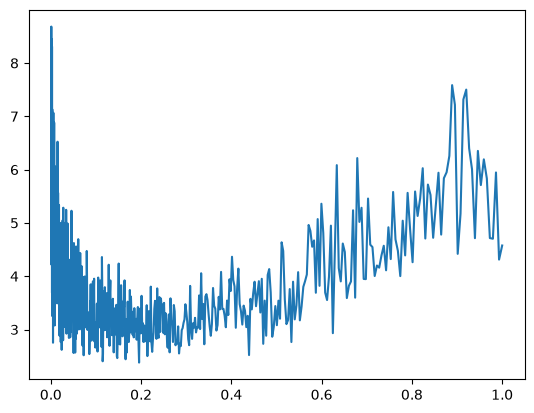

In [81]:
plt.plot(lri,lossi)

In [82]:
#我们可以看到这个loss曲线的分布
#一开始步长很小，所以loss变化也不大
#到了某一个区间突然开始发力，loss猛猛掉
#然后超过了某一个阈值开始不稳定了，于是开始飘忽不定了
#但是同时会发现这个东西他在横轴上是指数分布的
#所以我们可以换一个坐标看看

In [83]:
lri=[]
lossi=[]
for i in range(1000):
    ix=torch.randint(1,X.shape[0],(32,))
    emb = C[X[ix]] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss=F.cross_entropy(logits,Y[ix])
    #反向传播
    for p in parameters:
        p.grad=None
    loss.backward()

    lr=lrs[i]
    for p in parameters:
        p.data+=-lr*p.grad

    lri.append(lre[i])#横坐标换成-3～0的均匀分布
    lossi.append(loss.item())

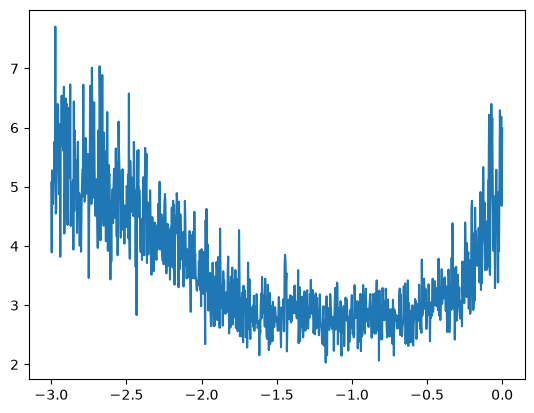

In [84]:
plt.plot(lri,lossi)

In [85]:
#这个就容易看很多了，可以看到loss在稳步下降，过了某个阈值之后开始急剧上升，说明不稳定了
#大概估计一下，步长设置在-0.1左右就很不错
#那我们重新来训练

In [86]:
g = torch.Generator().manual_seed(2147483647) #固定随机数
C = torch.randn((27, 2), generator=g)#嵌入层
W1 = torch.randn((6, 100), generator=g)#隐藏层
b1 = torch.randn(100, generator=g)#隐藏层
W2 = torch.randn((100, 27), generator=g)#激活层
b2 = torch.randn(27, generator=g)#激活层
parameters = [C, W1, b1, W2, b2]#所有的总参数，用于后续的梯度清除
for p in parameters:
    p.requires_grad=True

block_size=3

X,Y=[],[]

for w in words:
    context=[0]*block_size
    for ch in w+'.':
        ix=stoi[ch]
        X.append(context)
        Y.append(ix)
        context=context[1:]+[ix]

X=torch.tensor(X)
Y=torch.tensor(Y)

In [87]:
for i in range(100000):
    ix=torch.randint(1,X.shape[0],(32,))
    emb = C[X[ix]] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss=F.cross_entropy(logits,Y[ix])
    #反向传播
    for p in parameters:
        p.grad=None
    loss.backward()

    for p in parameters:
        p.data+=-0.1*p.grad

emb = C[X] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss=F.cross_entropy(logits,Y)       
print(f"最终结果:整体loss={loss}")

最终结果:整体loss=2.3312220573425293


In [88]:
#可以看到我们的最终loss已经低于之前的bigram了，说明我们的训练卓有成效
#可以反复运行上一个单元格，会发现loss在一直下降

In [89]:
#并且在真实训练中我们往往在训练后期会采用比较低的梯度，这样的话可以有效地精确训练
for i in range(100000):
    ix=torch.randint(1,X.shape[0],(32,))
    emb = C[X[ix]] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss=F.cross_entropy(logits,Y[ix])
    #反向传播
    for p in parameters:
        p.grad=None
    loss.backward()

    for p in parameters:
        p.data+=-0.01*p.grad

emb = C[X] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss=F.cross_entropy(logits,Y)       
print(f"最终结果:整体loss={loss}")

最终结果:整体loss=2.2567641735076904


In [90]:
#如果你亲自试试的话会发现调整过后loss的下降依旧明显

In [91]:
#现在我们发现我们模型的loss比以前低了很多
#理论上来说：我们如果持续训练甚至可能得到一个接近于0的成果

In [92]:
#但是我们要意识到一个问题：过拟合
#如果说我们的loss接近于0，说明模型几乎完全正确
#但也就意味着模型只会吐出正确答案，成为了背题机器而不是学习机器
#所以在开发过程中一般会把数据集分成三块：训练集，开发集（验证集），测试集
#开发集是在开发过程中进行测试的数据集，用于调整超参数，测试集是最后生成报告的数据集
#一般是80%，10%，10%这样分配

In [93]:
def build_dataset(words):#依据words构建数据集的函数
  block_size = 3 # 字符块大小
  X, Y = [], []
  for w in words:

    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)  
      context = context[1:] + [ix] 

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)#打印数据集的大小
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])#0%~80%
Xdev, Ydev = build_dataset(words[n1:n2])#80%~90%
Xte, Yte = build_dataset(words[n2:])#90~100%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [94]:
#这段代码可以把总的words依据n1n2两个节点分成三部分

In [95]:
#所以后面我们再进行训练的时候只使用Xtr和Ytr进行训练

In [96]:
g = torch.Generator().manual_seed(2147483647) #固定随机数
C = torch.randn((27, 2), generator=g)#嵌入层
W1 = torch.randn((6, 100), generator=g)#隐藏层
b1 = torch.randn(100, generator=g)#隐藏层
W2 = torch.randn((100, 27), generator=g)#激活层
b2 = torch.randn(27, generator=g)#激活层
parameters = [C, W1, b1, W2, b2]#所有的总参数，用于后续的梯度清除
for p in parameters:
    p.requires_grad=True

Xtr, Ytr = build_dataset(words[:n1])#0%~80%
Xdev, Ydev = build_dataset(words[n1:n2])#80%~90%
Xte, Yte = build_dataset(words[n2:])#90~100%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [97]:
for i in range(100000):
    ix=torch.randint(1,Xtr.shape[0],(32,))
    emb = C[Xtr[ix]] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss=F.cross_entropy(logits,Ytr[ix])
    #反向传播
    for p in parameters:
        p.grad=None
    loss.backward()

    for p in parameters:
        p.data+=-0.1*p.grad

emb = C[Xtr] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss=F.cross_entropy(logits,Ytr)       
print(f"最终结果:整体loss={loss.item()}")

最终结果:整体loss=2.3190014362335205


In [98]:
#接下来我们用验证集来进行判断

emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss=F.cross_entropy(logits,Ydev)       
print(f"loss={loss.item()}")

loss=2.3228566646575928


In [99]:
#大概是2.35
#这里的意义是，神经网络是没有见过这份验证集的，所以这样测出来的数字是有真实性的
#就好比我们考试的时候如果直接给平时作业原题那就没有效果了
#只有出一些新题考学生才行

In [100]:
#同时这也可以判断是否过拟合，这很好理解
#如果一个平时是认真做题的学生，那他考试的时候应该也会做得不错
#如果一个平时是背题目背答案的学生，那面对新题目的时候往往也不太行
#这就是两组数据的意义
#如果验证集的loss明显远大于训练集，那就应该出现了过拟合情况

In [101]:
#但是我们现在的这个模型也一般
#因为训练集和验证集的loss太接近了
#这就是所谓的“欠拟合”
#这通常意味着我们的神经网络太小了，就是说“笨笨的”，不太能学会东西
#所以下一步我们的目标就是扩建这个神经网络

In [102]:
#最简单的扩建方法就是直接增加隐藏层的大小

In [103]:
g = torch.Generator().manual_seed(2147483647) #固定随机数
C = torch.randn((27, 2), generator=g)#嵌入层
W1 = torch.randn((6, 300), generator=g)#扩建到300个神经元
b1 = torch.randn(300, generator=g)#隐藏层
W2 = torch.randn((300, 27), generator=g)#激活层
b2 = torch.randn(27, generator=g)#激活层
parameters = [C, W1, b1, W2, b2]#所有的总参数，用于后续的梯度清除
for p in parameters:
    p.requires_grad=True

Xtr, Ytr = build_dataset(words[:n1])#0%~80%
Xdev, Ydev = build_dataset(words[n1:n2])#80%~90%
Xte, Yte = build_dataset(words[n2:])#90~100%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [104]:
stepi=[]#用于后续画图
lossi=[]
for i in range(30000):#训练轮次少一些
    ix=torch.randint(1,Xtr.shape[0],(32,))
    emb = C[Xtr[ix]] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss=F.cross_entropy(logits,Ytr[ix])
    #反向传播
    for p in parameters:
        p.grad=None
    loss.backward()

    for p in parameters:
        p.data+=-0.1*p.grad
    stepi.append(i)
    lossi.append(loss.item())

emb = C[Xtr] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss=F.cross_entropy(logits,Ytr)       
print(f"最终结果:整体loss={loss.item()}")

最终结果:整体loss=2.5541021823883057


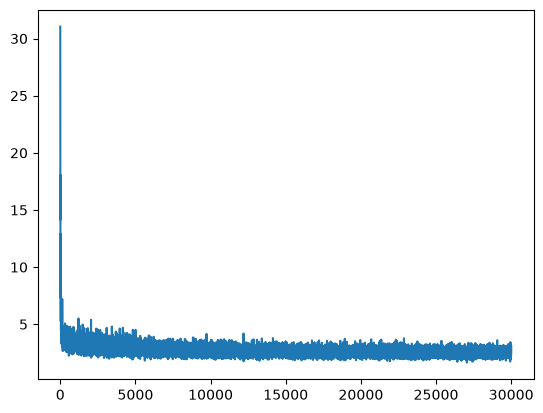

In [105]:
plt.plot(stepi,lossi)

In [106]:
#可以看到在下降，同时还有一定的波动，这是小规模数据会引入噪声而导致的

In [107]:
emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss=F.cross_entropy(logits,Ydev)       
print(f"loss={loss.item()}")

loss=2.549755096435547


In [108]:
#验证集的结果是2.5左右，说明我们的优化还不到位

In [109]:
#因为神经网络在扩大了之后往往需要更多的轮次去学习
stepi=[]
lossi=[]
for i in range(100000):
    ix=torch.randint(1,Xtr.shape[0],(32,))
    emb = C[Xtr[ix]] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss=F.cross_entropy(logits,Ytr[ix])
    #反向传播
    for p in parameters:
        p.grad=None
    loss.backward()

    for p in parameters:
        p.data+=-0.1*p.grad
    stepi.append(i)
    lossi.append(loss.item())

emb = C[Xtr] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss=F.cross_entropy(logits,Ytr)       
print(f"最终结果:整体loss={loss.item()}")

最终结果:整体loss=2.3217010498046875


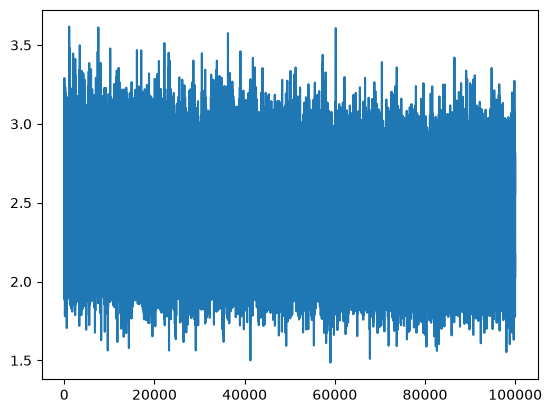

In [110]:
plt.plot(stepi,lossi)

In [111]:
#可以发现下降的很不明显了，这说明很有可能是我们的步长设置的不合适了
#因为神经网络在扩大了之后往往需要更多的轮次去学习
stepi=[]
lossi=[]
for i in range(100000):
    ix=torch.randint(1,Xtr.shape[0],(32,))
    emb = C[Xtr[ix]] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss=F.cross_entropy(logits,Ytr[ix])
    #反向传播
    for p in parameters:
        p.grad=None
    loss.backward()

    for p in parameters:
        p.data+=-0.01*p.grad
    stepi.append(i)
    lossi.append(loss.item())

emb = C[Xtr] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss=F.cross_entropy(logits,Ytr)       
print(f"最终结果:整体loss={loss.item()}")

最终结果:整体loss=2.2154030799865723


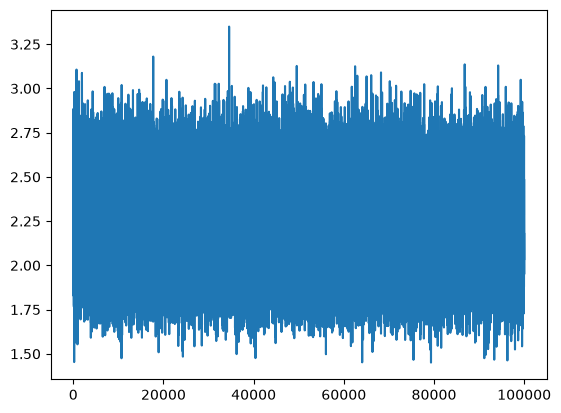

In [112]:
plt.plot(stepi,lossi)

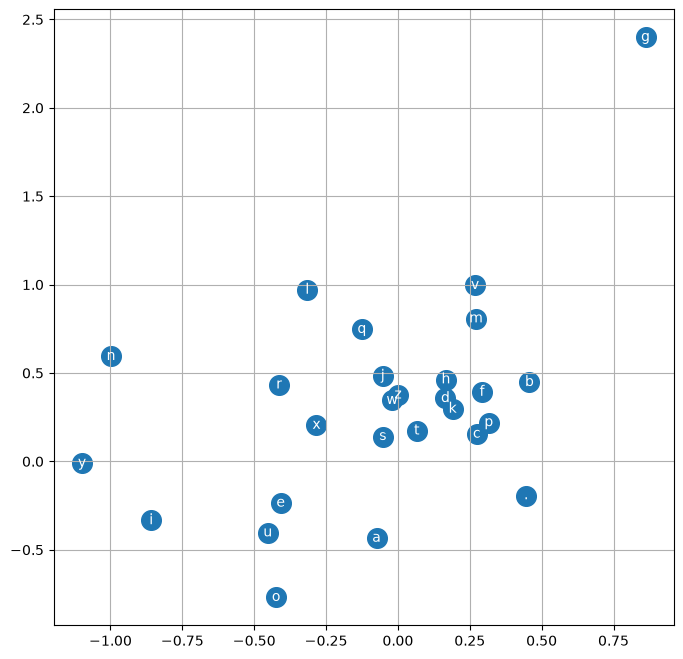

In [113]:
#还是不太行。
#andrej提出了种种可能：
#也许是因为我们的分组大小太小
#也许是我们的嵌入向量太小
#也许是我们步长不合适
#......
#这里andrej先来考虑增加我们的嵌入向量的维度
#首先我们先来看一下我们现有的嵌入向量
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')
#这里的显示方式是把二维的向量放到了平面直角坐标系里

In [114]:
#回顾论文：嵌入向量会反映字母的意义，意义接近的字符会聚集到一起
#我们可以看到这个还是学到不少的，比如元音aeiou就很接近
#说明神经网络认为这几个字符关联接近，甚至可以被认为是可以互相替换的
#也可以发现神经网络认为g和q是非常特殊的两个字母，里大部队非常遥远
#这就是我们在神经网络中遇到的第一个“涌现行为”
#我们没有任何一行代码跟他说：“你把相似的字母聚集到一起，不相干的相互远离”，只是在很多轮训练后模型自发的进行了位置区分/

In [115]:
#所以我们来扩建一下我们的嵌入向量维度,比如扩建到10维
g = torch.Generator().manual_seed(2147483647) #固定随机数
C = torch.randn((27, 10), generator=g)#嵌入层
W1 = torch.randn((30, 200), generator=g)#缩小到200个
b1 = torch.randn(200, generator=g)#隐藏层
W2 = torch.randn((200, 27), generator=g)#激活层
b2 = torch.randn(27, generator=g)#激活层
parameters = [C, W1, b1, W2, b2]#所有的总参数，用于后续的梯度清除
print(f"总参数量：{sum(p.nelement() for p in parameters)}")
for p in parameters:
    p.requires_grad=True

Xtr, Ytr = build_dataset(words[:n1])#0%~80%
Xdev, Ydev = build_dataset(words[n1:n2])#80%~90%
Xte, Yte = build_dataset(words[n2:])#90~100%

总参数量：11897
torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [116]:
stepi=[]
lossi=[]
i=0

In [117]:
n=i+50000
while(i<n):
    ix=torch.randint(1,Xtr.shape[0],(32,))
    
    emb = C[Xtr[ix]] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss=F.cross_entropy(logits,Ytr[ix])

    for p in parameters:
        p.grad=None
    loss.backward()

    for p in parameters:
        p.data+=-0.1*p.grad
    stepi.append(i)
    lossi.append(loss.log10().item())#这一步可以让后续的画图更加柔和
    i+=1

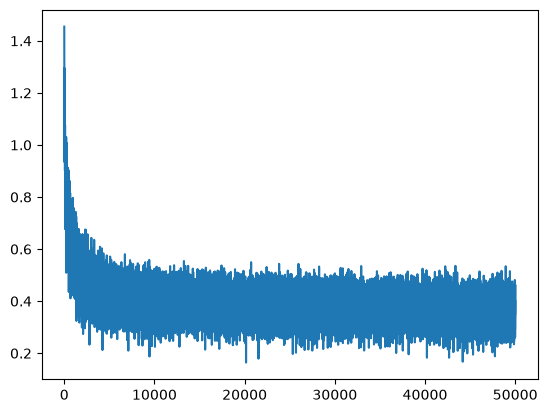

In [118]:
plt.plot(stepi,lossi)

In [119]:
emb = C[Xtr] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2 # (32, 27)
loss=F.cross_entropy(logits,Ytr)       
print(f"训练集loss={loss.item()}")

训练集loss=2.375344753265381


In [120]:
emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2 # (32, 27)
loss=F.cross_entropy(logits,Ydev)       
print(f"验证集loss={loss.item()}")

验证集loss=2.3965566158294678


In [121]:
#看起来效果很不错，我们进一步降低步长试试看
n=i+50000
while(i<n):
    ix=torch.randint(1,Xtr.shape[0],(32,))
    
    emb = C[Xtr[ix]] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss=F.cross_entropy(logits,Ytr[ix])

    for p in parameters:
        p.grad=None
    loss.backward()

    for p in parameters:
        p.data+=-0.01*p.grad
    stepi.append(i)
    lossi.append(loss.log10().item())
    i+=1

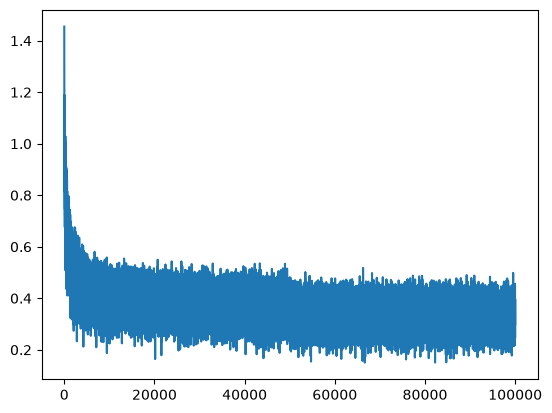

In [122]:
plt.plot(stepi,lossi)

In [123]:
emb = C[Xtr] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2 # (32, 27)
loss=F.cross_entropy(logits,Ytr)       
print(f"训练集loss={loss.item()}")

训练集loss=2.180274724960327


In [124]:
emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2 # (32, 27)
loss=F.cross_entropy(logits,Ydev)       
print(f"验证集loss={loss.item()}")

验证集loss=2.203350782394409


训练集loss=2.171916961669922
验证集loss=2.195899486541748


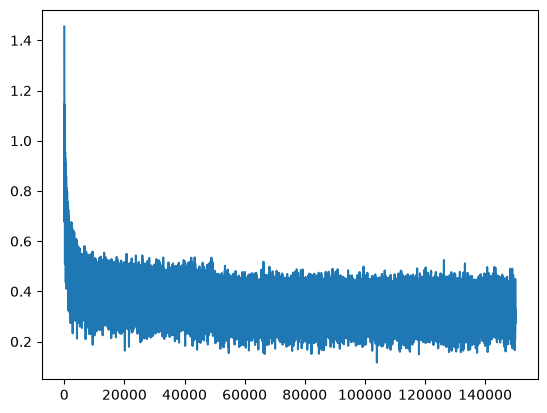

In [125]:
#可以看到我们的loss突破了2.3
#再来一次
#看起来效果很不错，我们进一步降低步长试试看
n=i+50000
while(i<n):
    ix=torch.randint(1,Xtr.shape[0],(32,))
    
    emb = C[Xtr[ix]] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss=F.cross_entropy(logits,Ytr[ix])

    for p in parameters:
        p.grad=None
    loss.backward()

    for p in parameters:
        p.data+=-0.01*p.grad
    stepi.append(i)
    lossi.append(loss.log10().item())
    i+=1

emb = C[Xtr] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2 # (32, 27)
loss=F.cross_entropy(logits,Ytr)       
print(f"训练集loss={loss.item()}")

emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2 # (32, 27)
loss=F.cross_entropy(logits,Ydev)       
print(f"验证集loss={loss.item()}")

plt.plot(stepi,lossi)

In [126]:
#可以看到我们的loss下降已经非常有限了
#并且测试集loss和验证集loss已经开始有差距
#说明我们的模型基本已经达到极限，开始出现过拟合预兆

In [127]:
#事实上在开发过程中，我们所说的“炼丹”就是调整我们刚刚调整的那些超参数
#当我们测出某种参数组合在验证集上的效果非常好
#就可以跑一次测试集，得到一个结果然后发论文表示自己找到了一个非常好的模型参数
#这就是ai炼丹的本质

In [128]:
#比如我们可以进一步调整：中间层的大小，嵌入向量大小，以及字符块的大小等等等等
#总之：神经网络是一个参数非常多的数据结构，同时人类也很难搞清楚到底参数取多少可以让loss最小
#所以就不停的试试试

总参数量：11897
torch.Size([182580, 3]) torch.Size([182580])
torch.Size([22767, 3]) torch.Size([22767])
torch.Size([22799, 3]) torch.Size([22799])
训练集loss=2.5004117488861084
验证集loss=2.5120182037353516


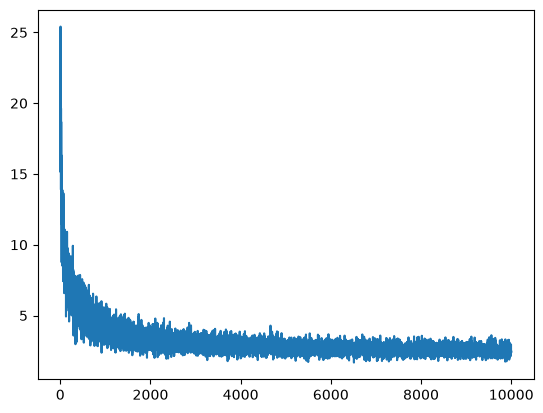

In [129]:
#比如说我们可以把所有的超参数拿出来，组成我们的“旋钮”
#同学可以试试看，调一调这些旋钮看看效果如何

#固定参数
vocab_size=27
g = torch.Generator().manual_seed(2147483647)

#旋钮
block_size=3
n_embd=10
n_hidden=200
n_steps=10000
batch_size=32
lr=0.1

#超参数
C = torch.randn((vocab_size, n_embd), generator=g)#嵌入层
W1 = torch.randn((block_size*n_embd,n_hidden), generator=g)#缩小到200个
b1 = torch.randn(n_hidden,generator=g)#隐藏层
W2 = torch.randn((n_hidden, vocab_size), generator=g)#激活层
b2 = torch.randn(vocab_size, generator=g)#激活层
parameters = [C, W1, b1, W2, b2]#所有的总参数，用于后续的梯度清除
print(f"总参数量：{sum(p.nelement() for p in parameters)}")
for p in parameters:
    p.requires_grad=True

#构建数据集
def build_dataset(words,block_size):
  X, Y = [], []
  for w in words:

    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)  
      context = context[1:] + [ix] 

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)#打印数据集的大小
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1],block_size)
Xdev, Ydev = build_dataset(words[n1:n2],block_size)
Xte, Yte = build_dataset(words[n2:],block_size)

#绘图参数
stepi=[]
lossi=[]

#训练
for i in range(n_steps):
    
    #前向传播
    ix=torch.randint(1,Xtr.shape[0],(batch_size,))
    emb = C[Xtr[ix]] 
    h = torch.tanh(emb.view(batch_size, block_size*n_embd) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 
    loss=F.cross_entropy(logits,Ytr[ix])
    
    #清空梯度
    for p in parameters:
        p.grad=None
    
    #反向传播
    loss.backward()

    #更新梯度
    for p in parameters:
        p.data+=-lr*p.grad

    #存储参数
    stepi.append(i)
    lossi.append(loss.item())

emb = C[Xtr]
h = torch.tanh(emb.view(-1, block_size*n_embd) @ W1 + b1)
logits = h @ W2 + b2
loss=F.cross_entropy(logits,Ytr)       
print(f"训练集loss={loss.item()}")

emb = C[Xdev]
h = torch.tanh(emb.view(-1, block_size*n_embd) @ W1 + b1)
logits = h @ W2 + b2 
loss=F.cross_entropy(logits,Ydev)       
print(f"验证集loss={loss.item()}")

plt.plot(stepi,lossi)

总参数量：52097
训练集loss=3.5403807163238525
验证loss=3.594465970993042
torch.Size([22781, 27])


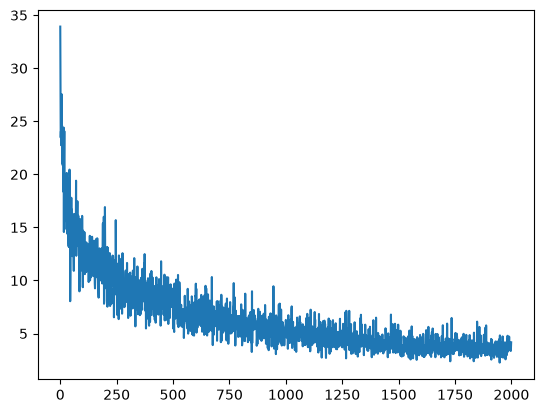

In [130]:
#甚至我们可以再创建一个变量：神经网络层数

#固定参数
vocab_size=27
g = torch.Generator().manual_seed(2147483647)

#旋钮
block_size=3
n_embd=10
n_steps=2000#先设置小一点，冒烟就好
batch_size=32
lr=0.1
layer_size=[block_size*n_embd,200,200,vocab_size]

Ws=[]
bs=[]

#超参数
C = torch.randn((vocab_size, n_embd), generator=g)#嵌入层

#神经网络层
for n1,n2 in zip(layer_size[:-1],layer_size[1:]):
    Ws.append(torch.randn((n1,n2), generator=g))
    bs.append(torch.randn(n2,generator=g))
    
parameters = [C]+Ws+bs#所有的总参数，用于后续的梯度清除

print(f"总参数量：{sum(p.nelement() for p in parameters)}")
for p in parameters:
    p.requires_grad=True

#构建数据集
def build_dataset(words,block_size):
  X, Y = [], []
  for w in words:

    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)  
      context = context[1:] + [ix] 

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1],block_size)
Xdev, Ydev = build_dataset(words[n1:n2],block_size)
Xte, Yte = build_dataset(words[n2:],block_size)

#绘图参数
stepi=[]
lossi=[]

#训练
for i in range(n_steps):
    
    #前向传播
    ix=torch.randint(1,Xtr.shape[0],(batch_size,))
    emb = C[Xtr[ix]] 
    x = emb.view(batch_size, block_size * n_embd)
    for W, b in zip(Ws[:-1], bs[:-1]):
        x = torch.tanh(x @ W + b)     
    logits = x @ Ws[-1] + bs[-1]                    
    loss=F.cross_entropy(logits,Ytr[ix])
    
    #清空梯度
    for p in parameters:
        p.grad=None
    
    #反向传播
    loss.backward()

    #更新梯度
    for p in parameters:
        p.data+=-lr*p.grad

    #存储参数
    stepi.append(i)
    lossi.append(loss.item())

emb = C[Xtr] 
x = emb.view(-1, block_size*n_embd)
for W, b in zip(Ws[:-1], bs[:-1]):
    x = torch.tanh(x @ W + b)     
logits = x @ Ws[-1] + bs[-1]               
loss=F.cross_entropy(logits,Ytr)
print(f"训练集loss={loss.item()}")


emb = C[Xdev] 
x = emb.view(-1, block_size*n_embd)
for W, b in zip(Ws[:-1], bs[:-1]):
    x = torch.tanh(x @ W + b)     
logits = x @ Ws[-1] + bs[-1]                  
loss=F.cross_entropy(logits,Ydev)
print(f"验证loss={loss.item()}")

plt.plot(stepi,lossi)
print(logits.shape)

总参数量：180707
训练集loss=2.314277172088623
验证集loss=2.4162662029266357


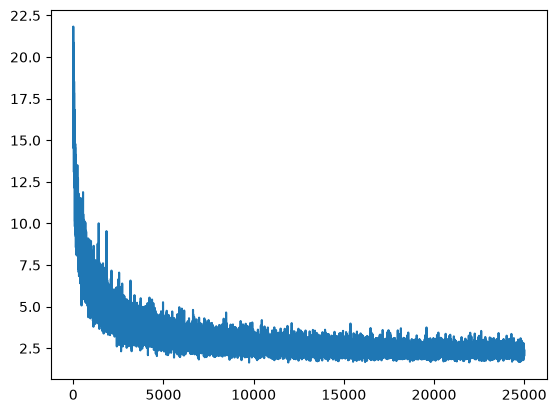

In [137]:
#训练成功
#但是loss不是太低，有很多种方面的原因
#同学可以自己试试看，调一调参数

#固定参数
vocab_size=27
g = torch.Generator().manual_seed(2147483647)

#旋钮
block_size=3
n_embd=40
n_steps=100000
batch_size=50
lr=0.03
layer_size=[block_size*n_embd,800,100,vocab_size]

Ws=[]
bs=[]

#超参数
C = torch.randn((vocab_size, n_embd), generator=g)#嵌入层

#神经网络层
for n1,n2 in zip(layer_size[:-1],layer_size[1:]):
    Ws.append(torch.randn((n1,n2), generator=g))
    bs.append(torch.randn(n2,generator=g))
    
parameters = [C]+Ws+bs#所有的总参数，用于后续的梯度清除

print(f"总参数量：{sum(p.nelement() for p in parameters)}")
for p in parameters:
    p.requires_grad=True

#构建数据集
def build_dataset(words,block_size):
  X, Y = [], []
  for w in words:

    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)  
      context = context[1:] + [ix] 

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1],block_size)
Xdev, Ydev = build_dataset(words[n1:n2],block_size)
Xte, Yte = build_dataset(words[n2:],block_size)

#绘图参数
stepi=[]
lossi=[]

#训练
for i in range(n_steps):
    
    #前向传播
    ix=torch.randint(1,Xtr.shape[0],(batch_size,))
    emb = C[Xtr[ix]] 
    x = emb.view(-1, block_size * n_embd)
    for W, b in zip(Ws[:-1], bs[:-1]):
        x = torch.tanh(x @ W + b)     
    logits = x @ Ws[-1] + bs[-1]                    
    loss=F.cross_entropy(logits,Ytr[ix])
    
    #清空梯度
    for p in parameters:
        p.grad=None
    
    #反向传播
    loss.backward()

    #更新梯度
    for p in parameters:
        p.data+=-lr*p.grad

    #存储参数
    stepi.append(i)
    lossi.append(loss.item())

emb = C[Xtr] 
x = emb.view(-1, block_size*n_embd)
for W, b in zip(Ws[:-1], bs[:-1]):
    x = torch.tanh(x @ W + b)     
logits = x @ Ws[-1] + bs[-1]               
loss=F.cross_entropy(logits,Ytr)
print(f"训练集loss={loss.item()}")


emb = C[Xdev] 
x = emb.view(-1, block_size*n_embd)
for W, b in zip(Ws[:-1], bs[:-1]):
    x = torch.tanh(x @ W + b)     
logits = x @ Ws[-1] + bs[-1]                  
loss=F.cross_entropy(logits,Ydev)
print(f"验证集loss={loss.item()}")

plt.plot(stepi,lossi)

In [132]:
#这已经是我能下降的最低最低的loss了😭
#反正我试出来的是，单纯的增加层数效果很一般，其实调大单层的规模和embd的大小挺有效的

In [133]:
#接下来既然我们已经生成了模型，那下一步要做的事情就是要用我们的模型来生成姓名
g = torch.Generator().manual_seed(2147483647+10)#换个种子

for i in range(20):#生成20个名字
    context=[0]*block_size#上下文。由于我们所有名字的开头全部都是一串点，所以我们可以直接用这个
    out=[]#输出

    while True:#用循环来生成姓名，直到出现'.'
        emb = C[torch.tensor(context)] 
        x = emb.view(-1, block_size*n_embd)
        for W, b in zip(Ws[:-1], bs[:-1]):
            x = torch.tanh(x @ W + b)     
        logits = x @ Ws[-1] + bs[-1] #一样计算出logits
        probs=F.softmax(logits,dim=1)#loss的计算用的是cross_entropy，现在用softmax计算probs
        ix=torch.multinomial(probs,num_samples=1,generator=g).item()#根据概率输出词汇
        context=context[1:]+[ix]
        out.append(itos[ix])
        if ix==0:
            break
    print(''.join(s for s in out))

carpah.
amelle.
khi.
mre.
reita.
halaysie.
rahnevalee.
rhy.
kaeli.
nellara.
chaihrin.
leig.
dhli.
jori.
quinthonova.
alianni.
wazelon.
jaryxtxik.
eveigh.
brex.


In [134]:
#同学可以对比下志之前我们在part1生成的名字，可以看到这次明显好了很多
#虽然有些还是有点怪，比如什么rryntn之类的
#但是结构和名字非常相似了！

In [135]:
#后面可能会出现训练进一步加重的情况，前面有一部分训练如果设置的轮次多的话很可能已经出现等待时间比较长的问题了
#所以后面andrej会提供一些google colab的版本去进行运行

In [136]:
#MakeMore Part2正式完结！